[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Total data poin yang berhasil diambil: 4849
Data Training: 2394 | Data Testing: 2395

[Eksperimen 1/6] Melatih Model (LR: 0.01, Batch: 1)...
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

[Eksperimen 2/6] Melatih Model (LR: 0.001, Batch: 1)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

[Eksperimen 3/6] Melatih Model (LR: 0.01, Batch: 16)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

[Eksperimen 5/6] Melatih Model (LR: 0.01, Batch: 32)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

[Eksperimen 6/6] Melatih Model (LR: 0.001, Batch: 32)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

Hasil Training Kombinasi Parameter Bi-LSTM (Rasio 50:50)
 No  Neuron Optimizer  Learning Rate  Batch Size  Epoch   RMSE  MAPE (%)
  1      50      Adam          0.010           1      5 411.12      4.69
  2      50      Adam          0.001           1      5 149.51      1.76
  3      50      Adam          0.010          16      5 201.83      3.03
  4      50      Adam          0.001          16      5 191.20      2.56
  5      50      Adam          0.010          32      5 131.30      1.65
  6      50      Adam          0.001          32      5 151.16      2.01


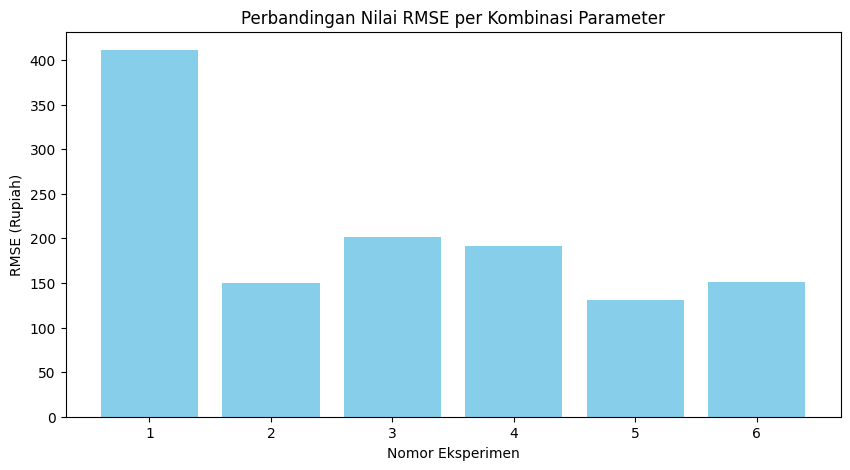

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# =================================================================
# 1. PENGAMBILAN DATA (11/11/2003 - 31/12/2023)
# =================================================================
ticker = "BBCA.JK"
# Gunakan auto_adjust=False agar kolom 'Close' tetap konsisten
df = yf.download(ticker, start="2003-11-11", end="2023-12-31", auto_adjust=False)

# Memastikan data terambil dan berbentuk 2D (baris, 1 kolom)
data = df[['Close']].values
print(f"Total data poin yang berhasil diambil: {len(data)}")

# =================================================================
# 2. NORMALISASI & WINDOWING
# =================================================================
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

prediction_days = 60
x_all, y_all = [], []

for x in range(prediction_days, len(scaled_data)):
    x_all.append(scaled_data[x-prediction_days:x, 0])
    y_all.append(scaled_data[x, 0])

x_all, y_all = np.array(x_all), np.array(y_all)
x_all = np.reshape(x_all, (x_all.shape[0], x_all.shape[1], 1))

# =================================================================
# 3. SPLIT DATA 50:50
# =================================================================
split_idx = int(len(x_all) * 0.5)
x_train, x_test = x_all[:split_idx], x_all[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

print(f"Data Training: {len(x_train)} | Data Testing: {len(x_test)}")

# =================================================================
# 4. INISIALISASI PARAMETER & LOOPING EKSPERIMEN
# =================================================================
configs = [
    {"neuron": 50, "lr": 0.01,  "batch": 1},
    {"neuron": 50, "lr": 0.001, "batch": 1},
    {"neuron": 50, "lr": 0.01,  "batch": 16},
    {"neuron": 50, "lr": 0.001, "batch": 16},
    {"neuron": 50, "lr": 0.01,  "batch": 32},
    {"neuron": 50, "lr": 0.001, "batch": 32}
]

summary_list = []

for i, cfg in enumerate(configs):
    print(f"\n[Eksperimen {i+1}/6] Melatih Model (LR: {cfg['lr']}, Batch: {cfg['batch']})...")

    # Membangun Arsitektur Bi-LSTM
    model = Sequential([
        Bidirectional(LSTM(cfg['neuron'], return_sequences=False), input_shape=(x_train.shape[1], 1)),
        Dense(25),
        Dense(1)
    ])

    # Inisialisasi Optimizer Adam
    optimizer = Adam(learning_rate=cfg['lr'])
    model.compile(optimizer=optimizer, loss='mean_squared_error')

    # Training
    model.fit(x_train, y_train, batch_size=cfg['batch'], epochs=5, verbose=0)

    # Prediksi pada Data Testing (50% terakhir)
    predictions = model.predict(x_test)

    # Invers Scaling (Kembali ke nilai harga asli Rupiah)
    predictions_unscaled = scaler.inverse_transform(predictions)
    y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Hitung Metrik Evaluasi
    rmse = np.sqrt(mean_squared_error(y_test_unscaled, predictions_unscaled))
    mape = mean_absolute_percentage_error(y_test_unscaled, predictions_unscaled) * 100

    summary_list.append({
        "No": i+1,
        "Neuron": cfg['neuron'],
        "Optimizer": "Adam",
        "Learning Rate": cfg['lr'],
        "Batch Size": cfg['batch'],
        "Epoch": 5,
        "RMSE": round(rmse, 2),
        "MAPE (%)": round(mape, 2)
    })

# =================================================================
# 5. MENAMPILKAN TABEL HASIL AKHIR
# =================================================================
results_df = pd.DataFrame(summary_list)
print("\n" + "="*75)
print("Hasil Training Kombinasi Parameter Bi-LSTM (Rasio 50:50)")
print("="*75)
print(results_df.to_string(index=False))
print("="*75)

# Visualisasi perbandingan RMSE
plt.figure(figsize=(10, 5))
plt.bar(results_df['No'].astype(str), results_df['RMSE'], color='skyblue')
plt.xlabel('Nomor Eksperimen')
plt.ylabel('RMSE (Rupiah)')
plt.title('Perbandingan Nilai RMSE per Kombinasi Parameter')
plt.show()

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


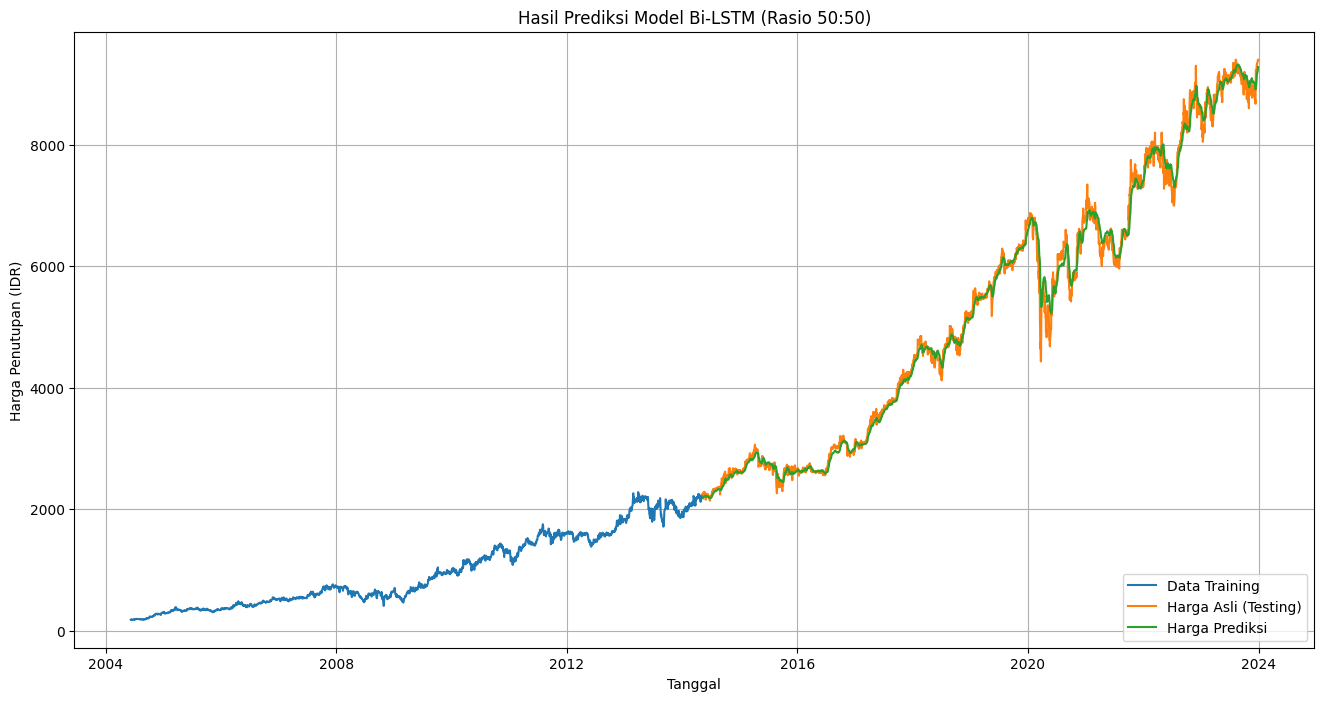

In [ ]:
# 1. Melakukan Prediksi menggunakan data testing (50% sisa)
predictions = model.predict(x_test)

# 2. Mengembalikan nilai ke skala asli (Rupiah)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# 3. Menyiapkan data untuk visualisasi
train_data = df[:split_idx + prediction_days]
valid_data = df[split_idx + prediction_days:].copy()
valid_data['Predictions'] = predictions

# 4. Visualisasi Hasil Prediksi vs Harga Asli
plt.figure(figsize=(16, 8))
plt.title('Hasil Prediksi Model Bi-LSTM (Rasio 50:50)')
plt.xlabel('Tanggal')
plt.ylabel('Harga Penutupan (IDR)')
plt.plot(train_data['Close'], label='Data Training')
plt.plot(valid_data['Close'], label='Harga Asli (Testing)')
plt.plot(valid_data['Predictions'], label='Harga Prediksi')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout

# Inisialisasi Model Sequential
model = Sequential()

# Menambahkan Layer Bi-LSTM
# return_sequences=False karena kita hanya butuh output di langkah terakhir
model.add(Bidirectional(LSTM(50, return_sequences=False), input_shape=(60, 1)))

# Menambahkan Dropout untuk regulasi
model.add(Dropout(0.2))

# Menambahkan Dense Layer (Hidden Layer)
model.add(Dense(25))

# Output Layer (1 Neuron untuk hasil prediksi harga)
model.add(Dense(1))

# Konfigurasi Training
model.compile(optimizer='adam', loss='mean_squared_error')

# Menampilkan Ringkasan Model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_7 (Bidirectional) │ (None, 100)            │        20,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,351 (91.21 KB)

 Trainable params: 23,351 (91.21 KB)

 Non-trainable params: 0 (0.00 B)